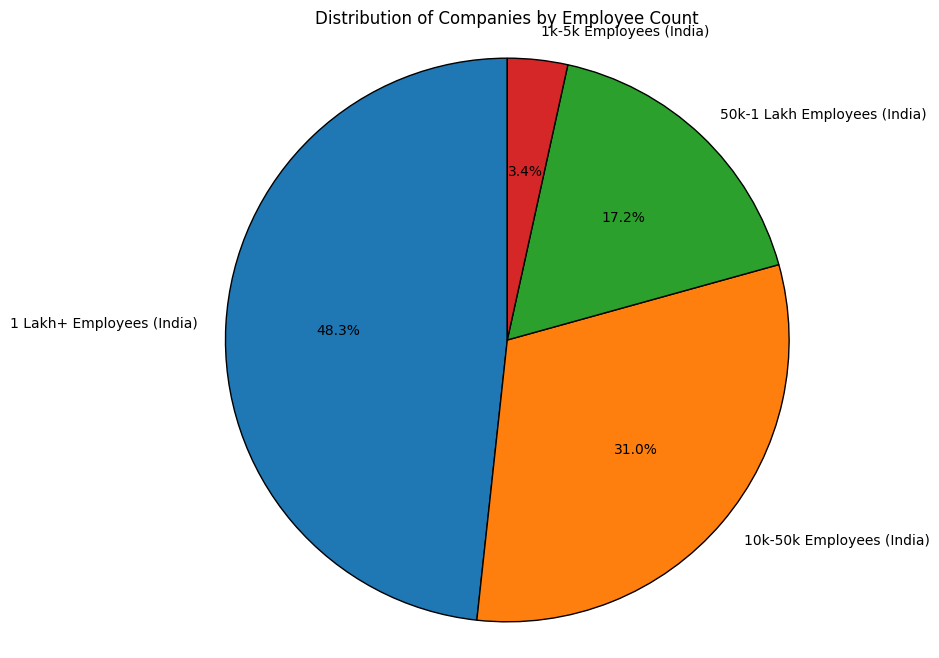

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(employee_counts, labels=employee_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Companies by Employee Count')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [27]:
display(hq_data.head(10))

,name,hq
0,TCS,"Mumbai,Maharashtra + 276 more"
1,Accenture,Dublin + 139 more
2,Cognizant,Teaneck. New Jersey. + 109 more
3,ICICI Bank,"Mumbai,Maharashtra + 1159 more"
4,Wipro,"Bangalore/Bengaluru,Karnataka + 235 more"
5,HDFC Bank,"Mumbai,Maharashtra + 1390 more"
6,Infosys,"Bengaluru/Bangalore,Karnataka + 132 more"
7,Capgemini,Paris + 81 more
8,Tech Mahindra,"Pune,Maharashtra + 221 more"
9,Genpact,"New York,New York + 76 more"


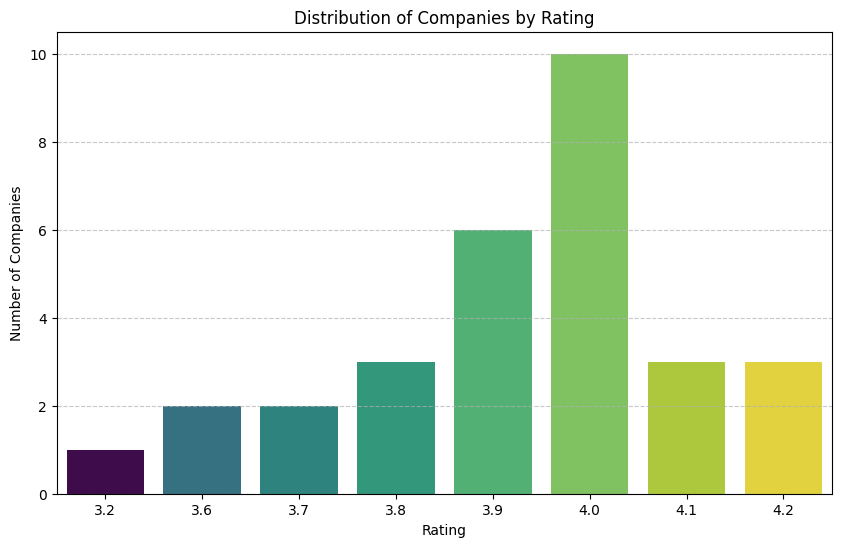

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Rating', y='Count', hue='Rating', data=rating_counts, palette='viridis', legend=False)
plt.title('Distribution of Companies by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Companies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

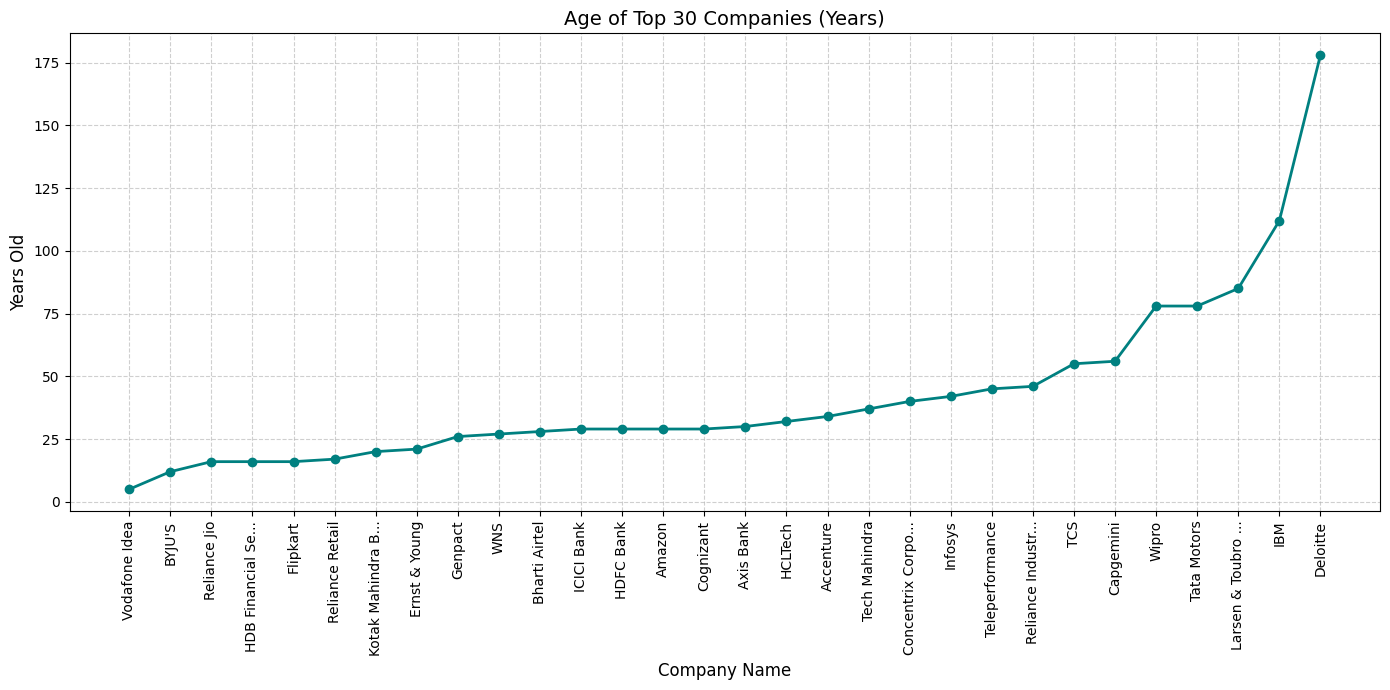

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Select the first 30 companies
df_30_years = df.head(30).copy()

# Function to extract numeric years from the 'years' column
def extract_years(val):
    if pd.isna(val): return 0
    val = str(val).lower()
    # Extract digits
    nums = ''.join(filter(str.isdigit, val))
    return int(nums) if nums else 0

df_30_years['years_old'] = df_30_years['years'].apply(extract_years)

# Sort by age for a cleaner line chart
df_30_years = df_30_years.sort_values(by='years_old')

plt.figure(figsize=(14, 7))
plt.plot(df_30_years['name'], df_30_years['years_old'], marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('Age of Top 30 Companies (Years)', fontsize=14)
plt.xlabel('Company Name', fontsize=12)
plt.ylabel('Years Old', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
import plotly.express as px
import pandas as pd

# Select the top 30 companies
df_30_funnel = df.head(30).copy()

# Function to clean and convert review counts
def parse_review_count(val):
    if pd.isna(val): return 0
    val = str(val).lower().replace('reviews', '').replace('(', '').replace(')', '').replace(',', '').strip()
    if 'k' in val:
        return float(val.replace('k', '')) * 1000
    try:
        return float(val)
    except:
        return 0

df_30_funnel['review_val'] = df_30_funnel['review_count'].apply(parse_review_count)

# Sort descending: highest reviews at top
df_30_funnel = df_30_funnel.sort_values(by='review_val', ascending=False)

fig = px.funnel(
    df_30_funnel,
    x='review_val',
    y='name',
    title='Top 30 Companies Funnel (by Review Count)',
    labels={'review_val': 'Number of Reviews', 'name': 'Company Name'}
)
fig.show()